<a href="https://colab.research.google.com/github/cansuzeynep/DL_course_material/blob/main/practicals/P1.2_Word_embedding_and_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline

In [2]:
# The first part of this practical is based on the tutorial by Robert Guthrie, which can be found here:
# https://pytorch.org/tutorials/beginner/nlp/word_embeddings_tutorial.html

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE

torch.manual_seed(1)

# Practical Overview

 In this Practical you will learn :
- Basic concepts of word embeddings.
- How to extract word embeddings by CBoW in a toy example.
- How to extract word embeddings by CBoW in `Alice in Wonderland`.
- Basic concepts of autoencoder
- How to learn a latent representation of MNIST
- How to use an autoencoder to decect fraud/anomaly

We recommend running the practicals of this course in Google Colab. Make sure to go to additional connection options (the small arrow at the top right) -> change runtime type -> a GPU runtime to make use of GPU acceleration.


# Word Embeddings: Encoding Lexical Semantics


Word embeddings are dense vectors of real numbers, one per word in your
vocabulary. In NLP, it is almost always the case that your features are
words! But how should you represent a word in a computer? You could
store its ascii character representation, but that only tells you what
the word *is*, it doesn't say much about what it *means* (you might be
able to derive its part of speech from its affixes, or properties from
its capitalization, but not much). Even more, in what sense could you
combine these representations? We often want dense outputs from our
neural networks, where the inputs are $|V|$ dimensional, where
$V$ is our vocabulary, but often the outputs are only a few
dimensional (if we are only predicting a handful of labels, for
instance). How do we get from a massive dimensional space to a smaller
dimensional space?

How about instead of ascii representations, we use a one-hot encoding?
That is, we represent the word $w$ by
$$
\begin{align}
\overbrace{\left[ 0, 0, \dots, 1, \dots, 0, 0 \right]}^\text{|V| elements}
\end{align}
$$

where the 1 is in a location unique to $w$. Any other word will
have a 1 in some other location, and a 0 everywhere else.

There is an enormous drawback to this representation, besides just how
huge it is. It basically treats all words as independent entities with
no relation to each other. What we really want is some notion of
*similarity* between words. Why? Let's see an example.

Suppose we are building a language model. Suppose we have seen the
sentences

* The mathematician ran to the store.
* The physicist ran to the store.
* The mathematician solved the open problem.

in our training data. Now suppose we get a new sentence never before
seen in our training data:

* The physicist solved the open problem.

Our language model might do OK on this sentence, but wouldn't it be much
better if we could use the following two facts:

- We have seen  mathematician and physicist in the same role in a sentence. Somehow they
  have a semantic relation.
* We have seen mathematician in the same role  in this new unseen sentence
  as we are now seeing physicist.

and then infer that physicist is actually a good fit in the new unseen
sentence? This is what we mean by a notion of similarity: we mean
*semantic similarity*, not simply having similar orthographic
representations. It is a technique to combat the sparsity of linguistic
data, by connecting the dots between what we have seen and what we
haven't. This example of course relies on a fundamental linguistic
assumption: that words appearing in similar contexts are related to each
other semantically. This is called the [distributional
hypothesis](https://en.wikipedia.org/wiki/Distributional_semantics).


## Getting Dense Word Embeddings


How can we solve this problem? That is, how could we actually encode
semantic similarity in words? Maybe we think up some semantic
attributes. For example, we see that both mathematicians and physicists
can run, so maybe we give these words a high score for the "is able to
run" semantic attribute. Think of some other attributes, and imagine
what you might score some common words on those attributes.

If each attribute is a dimension, then we might give each word a vector,
like this:

$$
\begin{align}
q_\text{mathematician} = \left[ \overbrace{2.3}^\text{can run},
   \overbrace{9.4}^\text{likes coffee}, \overbrace{-5.5}^\text{majored in Physics}, \dots \right]
 \end{align}
$$

$$
\begin{align}
q_\text{physicist} = \left[ \overbrace{2.5}^\text{can run},
   \overbrace{9.1}^\text{likes coffee}, \overbrace{6.4}^\text{majored in Physics}, \dots \right]
\end{align}
$$

Then we can get a measure of similarity between these words by doing:

$$
\begin{align}
\text{Similarity}(\text{physicist}, \text{mathematician}) = q_\text{physicist} \cdot q_\text{mathematician}
\end{align}
$$


Although it is more common to normalize by the lengths:

\begin{align}\text{Similarity}(\text{physicist}, \text{mathematician}) = \frac{q_\text{physicist} \cdot q_\text{mathematician}}
   {\| q_\text{physicist} \| \| q_\text{mathematician} \|} = \cos (\phi)\end{align}

Where $\phi$ is the angle between the two vectors. That way,
extremely similar words (words whose embeddings point in the same
direction) will have similarity 1. Extremely dissimilar words should
have similarity -1.



You can think of the sparse one-hot vectors from the beginning of this
section as a special case of these new vectors we have defined, where
each word basically has similarity 0, and we gave each word some unique
semantic attribute. These new vectors are *dense*, which is to say their
entries are (typically) non-zero.

But these new vectors are a big pain: you could think of thousands of
different semantic attributes that might be relevant to determining
similarity, and how on earth would you set the values of the different
attributes? Central to the idea of deep learning is that the neural
network learns representations of the features, rather than requiring
the programmer to design them herself. So why not just let the word
embeddings be parameters in our model, and then be updated during
training? This is exactly what we will do. We will have some *latent
semantic attributes* that the network can, in principle, learn. Note
that the word embeddings will probably not be interpretable. That is,
although with our hand-crafted vectors above we can see that
mathematicians and physicists are similar in that they both like coffee,
if we allow a neural network to learn the embeddings and see that both
mathematicians and physicists have a large value in the second
dimension, it is not clear what that means. They are similar in some
latent semantic dimension, but this probably has no interpretation to
us.


In summary, **word embeddings are a representation of the *semantics* of
a word, efficiently encoding semantic information that might be relevant
to the task at hand**. You can embed other things too: part of speech
tags, parse trees, anything! The idea of feature embeddings is central
to the field.


## Word Embeddings in Pytorch


Before we get to a worked example and an exercise, a few quick notes
about how to use embeddings in Pytorch and in deep learning programming
in general. Similar to how we defined a unique index for each word when
making one-hot vectors, we also need to define an index for each word
when using embeddings. These will be keys into a lookup table. That is,
embeddings are stored as a $|V| \times D$ matrix, where $D$
is the dimensionality of the embeddings, such that the word assigned
index $i$ has its embedding stored in the $i$'th row of the
matrix. In all of code, the mapping from words to indices is a
dictionary named word\_to\_ix.

The module that allows you to use embeddings is torch.nn.Embedding,
which takes two arguments: the vocabulary size, and the dimensionality
of the embeddings.

To index into this table, you must use torch.LongTensor (since the
indices are integers, not floats).



In [3]:
word_to_ix = {"hello": 0, "world": 1}
embeds = nn.Embedding(2, 5)  # 2 words in vocab, 5 dimensional embeddings, 2x5 matrix
lookup_tensor = torch.tensor([word_to_ix["hello"]], dtype=torch.long)
print(lookup_tensor)
hello_embed = embeds(lookup_tensor) #opens row 0 and gets the 5 columns on that row
print(hello_embed)

tensor([0])
tensor([[ 0.6614,  0.2669,  0.0617,  0.6213, -0.4519]],
       grad_fn=<EmbeddingBackward0>)


## Practical part  1: Computing Word Embeddings -- Continuous Bag-of-Words in a Toy example


The Continuous Bag-of-Words model (CBOW) is frequently used in NLP deep
learning. It is a model that tries to predict words given the context of
a few words before and a few words after the target word. This is
distinct from typical practices in language modeling, since CBOW is not sequential and does
not have to be probabilistic. Typcially, CBOW is used to quickly train
word embeddings, and these embeddings are used to initialize the
embeddings of some more complicated model. Usually, this is referred to
as *pretraining embeddings*. It almost always helps performance a couple
of percent.

The CBOW model is as follows. Given a target word $w_i$ and an
$N$ context window on each side, $w_{i-1}, \dots, w_{i-N}$
and $w_{i+1}, \dots, w_{i+N}$, referring to all context words
collectively as $C$, CBOW tries to minimize

\begin{align}-\log p(w_i | C) = -\log \text{Softmax}(A(\sum_{w \in C} q_w) + b)\end{align}

where $q_w$ is the embedding for word $w$.

Implement this model in Pytorch by filling in the class below. Some
tips:

* Think about which parameters you need to define.
* Make sure you know what shape each operation expects. Use .view() if you need to
  reshape.



###  Data Preprocessing

The CBOW model architecture tries to predict the current target word (the center word) based on the source context words (surrounding words). Considering a simple sentence, `the quick brown fox jumps over the lazy dog`, this can be pairs of (context_window, target_word) where if we consider a context size 2 (2 words to the left, 2 to the right),  we have examples like `([the, quick, fox, jumps], brown)` and so on. Thus the model tries to predict the target_word based on the context_window words.


Therefore should build a list of tuples.  Each tuple is `([ word_i-2, word_i-1,word_i+1, word_i+2 ], target word)`, we also build dictionaries to map from words to indices, i.e. word_to_ix, and map from indices to words, i.e. ix_to_word,

In [4]:
import torch
import torch.nn as nn


CONTEXT_SIZE = 2  # 2 words to the left, 2 to the right
EMBEDDING_DIM = 100

raw_text = """We are about to study the idea of a computational process.
Computational processes are abstract beings that inhabit computers.
As they evolve, processes manipulate other abstract things called data.
The evolution of a process is directed by a pattern of rules
called a program. People create programs to direct processes. In effect,
we conjure the spirits of the computer with our spells.""".split()


# By deriving a set from `raw_text`, we deduplicate the array
vocab = set(raw_text) #strictly count unique words
vocab_size = len(vocab)
#we dont eliminate the words from the raw data though!!
word_to_ix = {word:ix for ix, word in enumerate(vocab)} #every unique word gets a number in the dictionary human -> comp
ix_to_word = {ix:word for ix, word in enumerate(vocab)} #comp -> human dict

data = []
for i in range(2, len(raw_text) - 2): #because we are looking for a 2 width window if it was 0 we couldnt look to the left
    context = [raw_text[i - 2], raw_text[i - 1],
               raw_text[i + 1], raw_text[i + 2]]
    target = raw_text[i]
    data.append((context, target))

print(data[:5])

[(['We', 'are', 'to', 'study'], 'about'), (['are', 'about', 'study', 'the'], 'to'), (['about', 'to', 'the', 'idea'], 'study'), (['to', 'study', 'idea', 'of'], 'the'), (['study', 'the', 'of', 'a'], 'idea')]


### Create CBoW Model
Following is an image to illustrate the model architecture. We set the word embedding size to be 100 (or other by your preference).

![avatar](https://miro.medium.com/max/328/1*bkrBASpteKfCaxZDEEeN6g.png)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F # Added this import

class CBOW(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        # === ADD CODE HERE ===
        super(CBOW, self).__init__()

        #1. define the word embeeding matrix, create a lookup table, turn IDs into vectors
        #how many words, how many numbers per word
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        #2. define the linear layer, turn vectors into words
        #the classifier, go back to the dict and find the word
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, inputs):
         # === ADD CODE HERE ===
         #move from INPUT -> OUTPUT
         embeds = self.embeddings(inputs)
         sum_embeds = sum(embeds).view(1, -1) #sum the vectors however pytorch needs 2D therefore turn them from 1D to 2D
         out = self.linear(sum_embeds) # Changed from 'embeds' to 'sum_embeds'
         log_probs = F.log_softmax(out, dim=1) #calc probabilities across the columns !!
         return log_probs

# create your model and train.  here are some functions to help you make
# the data ready for use by your module

# 1) PREPARE 2) ZERO 3) FORWARD 4) BACKWARD 5) STEP
def make_context_vector(context, word_to_ix):
    idxs = [word_to_ix[w] for w in context]
    return torch.tensor(idxs, dtype=torch.long)

model = CBOW(vocab_size, EMBEDDING_DIM)
loss_function = nn.NLLLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

#TRAINING
for epoch in range(50):
    # === ADD CODE HERE ===
    total_loss = 0
    for context, target in data:
        # Step 1. Prepare the inputs to be passed to the model (i.e, turn the words
        # into integer indices and wrap them in tensors)
        context_vector = make_context_vector(context, word_to_ix)

        # Step 2. Recall that torch *accumulates* gradients. Before passing in a
        # new instance, you need to zero out the gradients from the old
        # instance
        model.zero_grad()

        # Step 3. Run the forward pass, getting log probabilities over near
        # words
        log_probs = model(context_vector)

        # Step 4. Compute your loss function. (Again, Torch wants the target
        # word wrapped in a tensor)
        loss = loss_function(log_probs, torch.tensor([word_to_ix[target]], dtype=torch.long))

        # Step 5. Do the backward pass and update the gradient
        loss.backward()
        optimizer.step() #adjust weight

        # Get the Python number from a 1-element Tensor by calling tensor.item()
        total_loss += loss.item()
    average_loss= total_loss/len(data)
    print('Epoch:', epoch, '\tLoss:', average_loss)  # The loss decreased

Epoch: 0 	Loss: 4.452027063945244
Epoch: 1 	Loss: 4.026725136000534
Epoch: 2 	Loss: 3.632053926073272
Epoch: 3 	Loss: 3.2679635748781006
Epoch: 4 	Loss: 2.9344276354230683
Epoch: 5 	Loss: 2.6308678866460404
Epoch: 6 	Loss: 2.3559121833793046
Epoch: 7 	Loss: 2.107693050442071
Epoch: 8 	Loss: 1.884305427814352
Epoch: 9 	Loss: 1.6840050115153706
Epoch: 10 	Loss: 1.5051922392228554
Epoch: 11 	Loss: 1.346336934587051
Epoch: 12 	Loss: 1.205912668900243
Epoch: 13 	Loss: 1.0823641288383254
Epoch: 14 	Loss: 0.9741114383113796
Epoch: 15 	Loss: 0.8795749085216686
Epoch: 16 	Loss: 0.7972063961727865
Epoch: 17 	Loss: 0.725518956009684
Epoch: 18 	Loss: 0.6631149621359234
Epoch: 19 	Loss: 0.6087115401851719
Epoch: 20 	Loss: 0.561160175065542
Epoch: 21 	Loss: 0.5194551777736894
Epoch: 22 	Loss: 0.4827319873047286
Epoch: 23 	Loss: 0.45025692507624626
Epoch: 24 	Loss: 0.42141230686985215
Epoch: 25 	Loss: 0.3956801264450468
Epoch: 26 	Loss: 0.3726264653277808
Epoch: 27 	Loss: 0.3518873820530957
Epoch: 28

###  Check the results

Then we check the results by making predictions of target work by context

In [7]:
context = ['People','create','to', 'direct']
context_vector = make_context_vector(context, word_to_ix)
a = model(context_vector)

#Print result
print(f'Raw text: {" ".join(raw_text)}\n')
print(f'Context: {context}\n')
print(f'Prediction: {ix_to_word[torch.argmax(a[0]).item()]}')

Raw text: We are about to study the idea of a computational process. Computational processes are abstract beings that inhabit computers. As they evolve, processes manipulate other abstract things called data. The evolution of a process is directed by a pattern of rules called a program. People create programs to direct processes. In effect, we conjure the spirits of the computer with our spells.

Context: ['People', 'create', 'to', 'direct']

Prediction: programs


## Practical part 2: Computing Word Embeddings in  `Alice in Wonderland` using CBoW

Now let's try to build word embedding in a ‘Alice in Wonderland’ instead of a toy example. The word-label mapping dictionaries and corpus are available [here](https://drive.google.com/drive/folders/1mYM29PbWQ4rS0bgKndFJjZlkbcwMaEpO?usp=sharing). You can use the cell bellow to download the necessary data in your working directory.

In [8]:
import gdown
gdown.download_folder("https://drive.google.com/drive/folders/1mYM29PbWQ4rS0bgKndFJjZlkbcwMaEpO")

Retrieving folder contents


Processing file 1TGMG8jTqZBrJoJB_gGxd9vh8rtX7JuXw alice.json
Processing file 1ECyNDt0sb8PD9A5LN8YYSUb6vmb1uj6W ix_to_word.json
Processing file 1NYzP_0QSBFVNCZW6m7KAFA83LJUtU97Q word_to_ix.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1TGMG8jTqZBrJoJB_gGxd9vh8rtX7JuXw
To: /content/Word_embedding_data/alice.json
100%|██████████| 78.0k/78.0k [00:00<00:00, 4.50MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ECyNDt0sb8PD9A5LN8YYSUb6vmb1uj6W
To: /content/Word_embedding_data/ix_to_word.json
100%|██████████| 42.3k/42.3k [00:00<00:00, 13.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NYzP_0QSBFVNCZW6m7KAFA83LJUtU97Q
To: /content/Word_embedding_data/word_to_ix.json
100%|██████████| 37.6k/37.6k [00:00<00:00, 24.1MB/s]
Download completed


['/content/Word_embedding_data/alice.json',
 '/content/Word_embedding_data/ix_to_word.json',
 '/content/Word_embedding_data/word_to_ix.json']

###  Data Preprocessing

In [9]:
# modify the path according to your own file location
import os
data_path=os.path.join("/content/Word_embedding_data/")
# if you are not using Colab, change data_path above to where you stored the data locally

Now we load the data:

In [10]:
import json
with open(os.path.join(data_path,"alice.json"),'r') as f:
    alice = json.load(f)
with open(os.path.join(data_path,"ix_to_word.json"),'r') as f:
    ix_to_word = json.load(f)
with open(os.path.join(data_path,"word_to_ix.json"),'r') as f:
    word_to_ix = json.load(f)

Then we create the context and target pairs by borrowing some keras utilities. We set the window_size 2 (2 words to the left, 2 to the right).

In [11]:
window_size=2
vocab_size=len(word_to_ix)

from tensorflow.keras.preprocessing import text
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import pad_sequences

corpus = [[word_to_ix[w] for w in text.text_to_word_sequence(doc)] for doc in alice]
#list of sentences, where each sentence is a list of integers.

def generate_context_word_pairs(corpus, window_size, vocab_size):
    X = []
    Y = []
    context_length = window_size*2
    for words in corpus:
        sentence_length = len(words)
        for index, word in enumerate(words): #doesnt skips any words the outer ones as well unlike the prev
            start = index - window_size
            end = index + window_size + 1
            context = [words[i] for i in range(start, end)if 0 <= i < sentence_length and i != index]
            #0 <= i < sentence_length prevents the code from crashing when it hits the edges of sentences.
            #If a word is at index 0, trying to read index -2 is ignored.
            #i != index ensures it skips the target word itself, because we only want the surrounding context words.
            x = pad_sequences([context], maxlen=context_length)[0]
            #pad_sequences adds 0s to the beginning to make context arrays list make the max target length (4 -> -2 .. +2)
            X.append(x)
            Y.append([word])

    X=torch.tensor(X, dtype=torch.long)
    Y=torch.tensor(Y, dtype=torch.long)
    return X,Y

X,Y = generate_context_word_pairs(corpus, window_size=window_size, vocab_size=vocab_size)

/tmp/ipykernel_449/3117124266.py:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X=torch.tensor(X, dtype=torch.long)


###  Create CBoW Model
Now we create CBoW model, we could set the word embedding size to be 100 (or  some other number if you prefer).

In [16]:
class CBOW(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        # === ADD CODE HERE ===
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)
        # self.activation_function1 = nn.ReLU()

        # #out: 1 x vocab_size
        # self.linear2 = nn.Linear(128, vocab_size)

    def forward(self, inputs):
         # === ADD CODE HERE ===
         embeds = self.embeddings(inputs)
         sum_embeds = sum(embeds).view(1, -1)
         out = self.linear(sum_embeds)
         log_probs = F.log_softmax(out, dim=1)
         return log_probs


EMBEDDING_DIM=100
model = CBOW(vocab_size,EMBEDDING_DIM)

Remember to move your model to GPU, since now we are training with a larger corpus.

In [15]:
# Move model to GPU
# === ADD CODE HERE ===
device = torch.device("cuda" if torch.cuda.is_available() else torch.device("cpu"))
model.to(device)

CBOW(
  (embeddings): Embedding(49, 100)
  (linear): Linear(in_features=100, out_features=49, bias=True)
)

Then we train the model and print the loss. The loss should decrease with every epoch over the training data. You can play with the epochs numbers here.

In [23]:
#TRAINING

# Re-instantiate the CBOW model and move it to device to ensure the correct model is used
EMBEDDING_DIM=100 # Assuming EMBEDDING_DIM for CBOW is 100 as per previous cells
model = CBOW(vocab_size, EMBEDDING_DIM)
device = torch.device("cuda" if torch.cuda.is_available() else torch.device("cpu"))
model.to(device)

loss_function = nn.NLLLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# Ensure X and Y are on the correct device before starting the loop
X = X.to(device)
Y = Y.to(device)

for epoch in range(10):
# === ADD CODE HERE ===
  total_loss = 0
  i = 0
  for context, target in zip(X,Y):
    #previously we were loopimg over a list of raw text tuples
    #X and Y are now pre-compiled master tensors
    # Step 1. Recall that torch *accumulates* gradients. Before passing in a
    # new instance, you need to zero out the gradients from the old instance
    model.zero_grad()

    # Step 2. Run the forward pass, getting log probabilities.
    log_probs = model(context)
    #dev stands for device
    #DATA and MODEL must live in the same warehouse to work together
    #.to(dev) makes sure that the data is on the correct HW

    # Step 3. Compute your loss function.
    loss = loss_function(log_probs,target)

    # Step 5. Do the backward pass and update the gradient
    loss.backward()
    optimizer.step() #update model parameters

    # Get the Python number from a 1-element Tensor by calling tensor.item()
    total_loss += loss.item()
  average_loss= total_loss/len(X)
  print('Epoch:', epoch, '\tLoss:', average_loss)  # The loss decreased every iteration over the training data!


Epoch: 0 	Loss: 7.91913792615935
Epoch: 1 	Loss: 7.191862393297234
Epoch: 2 	Loss: 6.742570363324436
Epoch: 3 	Loss: 6.378570811001298
Epoch: 4 	Loss: 6.064230789274939
Epoch: 5 	Loss: 5.78624903078886
Epoch: 6 	Loss: 5.537249501934967
Epoch: 7 	Loss: 5.312285214697569
Epoch: 8 	Loss: 5.107596807137384
Epoch: 9 	Loss: 4.920160590563312


# Encoding the data in a low dimensional space using an autoencoder

While word embeddings allow us to capture the semantic meaning of discrete tokens (like words) into dense vectors, how can we compress and extract meaningful features from continuous, high-dimensional data? One solution is to use an *autoencoder*.

An autoencoder is a specific type of unsupervised artificial neural network designed to learn efficient encodings of unlabeled data. The network is trained to output a reconstruction that is as close to its original input as possible. To prevent the network from just trivially copying the input to the output (acting as an identity function), we introduce a *bottleneck* that forces the model to compress the data, thereby discovering and learning the most robust and important features of the dataset.

Structurally, an autoencoder consists of three main components:

* **The Encoder:** This part of the network compresses the high-dimensional input $x$ into a lower-dimensional latent representation $z$. Mathematically, this is a learned function $z = f(x)$.
* **The Bottleneck (Latent Space):** This is the compressed knowledge representation of the original input. Its dimensionality is strictly smaller than the input space, forcing the network to prioritize the most critical features needed for reconstruction.
* **The Decoder:** This network attempts to reconstruct the original input from the compressed latent space representation, producing an output $\hat{x}$. This is a learned function $\hat{x} = g(z)$.

The model is trained by minimizing the reconstruction error between the original input $x$ and the reconstructed output $\hat{x}$. A common choice for this loss function is the Mean Squared Error (MSE):

$$L(x, \hat{x}) = ||x - \hat{x}||^2$$

By training the network to minimize this loss, the latent vector $z$ becomes a dense, meaningful representation of the data. This low-dimensional space can then be used for downstream tasks.


## Practical part 3: Compressing MNIST

In this section, we will apply our autoencoder to the classic MNIST dataset of handwritten digits. Each image is $28 \times 28$ pixels, meaning it is originally represented by a 784-dimensional vector. Our goal is to compress this input into a much smaller, dense latent vector. To successfully reconstruct the image from this bottleneck, the network is forced to learn the core structural features of the digits.

### Loading data

In [19]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([ #chains indv. cleaning steps together so that every image runs through in order
    transforms.ToTensor(), #[height,width,channels] -> [channels, height, width] / 255.0 -> [0,1]
    transforms.Normalize((0.5,), (0.5,)) # (mean,), (std,) -> 1 single channel
                                 #if it was RGB and not 1 channel (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
])
#if the data is centered around 0 -> data contains an even balance of - and + coordinates
# Normalize steps in to shift decimal values using current pixel value - mean / std

train_dataset = torchvision.datasets.MNIST(root='./data',
                                               train=True,
                                               transform=transform,
                                               download=True)

test_dataset = torchvision.datasets.MNIST(root='./data',
                                              train=False,
                                              transform=transform,
                                              download=True)

print(f"MNIST Training dataset size: {len(train_dataset)}")
print(f"MNIST Test dataset size: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.67MB/s]

MNIST Training dataset size: 60000
MNIST Test dataset size: 10000


### Design the autoencoder

In the cell below, define an autoencoder with a feature vector of dimension *embedding_dim* as the bottleneck.

(While dense layers are sufficient to decent performance given the simplicity of the dataset, you can also experiment with convolution layers. In the scenario of a CNN autoencoder, you can use [upsampling](https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html ) or [deconvolution](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html) in the decoder. You can also take inspiration from tutorials/P2.2_U_net_segmentation.ipynb)



In [20]:
class AutoEncoder(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        # === ADD CODE HERE ===
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 100),
            nn.ReLU(),
            nn.Linear(100,embedding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 28*28)
        )

    def forward(self, x):
        # === ADD CODE HERE ===
        embedding = self.encoder(x.view(-1,28*28)) #linear layers cant see 2D images therefore -> 784 falt line of no
        reconstruction = self.decoder(embedding).view(-1,1,28,28) # 784 -> [1 channel, 28 height, 28 width]
        return reconstruction, embedding
EMBEDDING_DIM=20
model = AutoEncoder(EMBEDDING_DIM)

#ALTERNATIVE
class AutoEncoderCNN(nn.Module): #shrink width and height while inc channels (depth)
  def __init__(self, embedding_dim):
    super().__init__()
    assert embedding_dim % 2 == 0
    self.encoder = nn.Sequential(
        nn.Conv2d(1, embedding_dim//2, 3, padding="same"), #inc channels from 1 -> 10
        #(Input_Channels, Output_Channels, Kernel_Size, Padding)
        #It tells the layer to generate 10 unique feature-tracking channels
        #the layer uses a tiny $3 \times 3$ sliding window matrix (a filter) to scan across the image pixels to look for edges, curves, and lines.
        nn.ReLU(),
        nn.MaxPool2d(2), #2x2 grid of pixels and pick single max brightest, throwing other 3
        #divide by 2: 28 -> 14 shape becomes [20,14,14]
        nn.Conv2d(embedding_dim//2, embedding_dim, 3, padding="same"), #finds features
        nn.ReLU(),
        nn.MaxPool2d(2), # 14 -> 7 shape becomes [20,7,7] -> sned the loudest feature scores to the next level
        nn.Flatten(), #3D -> flat vector 980
        nn.Linear(embedding_dim*7*7, embedding_dim) #turn 980 to 20 dim as wanted
    )
    self.decoder = nn.Sequential(
        nn.Linear(embedding_dim, 7*7*embedding_dim), #20  -> 980
        nn.ReLU(),
        nn.Unflatten(1, (embedding_dim, 7, 7)), #line -> 3d grid shape [20 channel, 7 ,7]
        nn.Upsample(scale_factor=2, mode='nearest'), #[20, 14, 14]
        nn.Conv2d(embedding_dim, embedding_dim//2, 3, padding="same"), #[10, 14, 14]
        nn.ReLU(),
        nn.Upsample(scale_factor=2, mode='nearest'), # x2: 7 -> 14 -> 28 becomes [10, 28, 28]
        nn.Conv2d(embedding_dim//2, 1, 3, padding="same") #go back to original 10 -> 1
        #becomes [1,28,28]
    )
  def forward(self, x):
    embedding = self.encoder(x)
    reconstruction = self.decoder(embedding)
    return reconstruction, embedding


Now move the model to the GPU and train it using MSE.

In [21]:
# Move model to GPU
# === ADD CODE HERE ===
model.to("cuda")

# Train the model on MNIST
# === ADD CODE HERE ===
loss_fn = nn.MSELoss() #autoencoder doing reconstruction and not predicting smth use MSE
optimizer = optim.Adam(model.parameters()) #Adam autoamtically tunes the lr

for epoch in range(20):
    # === ADD CODE HERE ===
    total_loss = 0
    for images, _ in DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2):
        #because this is an autoencoder throw away the target digit label by assigning it to the underscore
        #use 2 background processing cores to pre-load the next batches of images ahead of time
        images = images.to("cuda")
        optimizer.zero_grad()
        reconstruction, _ = model(images)
        loss = loss_fn(reconstruction, images) #throw away the embedding that is also returned because we dont need it while calculating the error
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0) #loss item gives the avg loss of teh 32 images in that batch
        #image.size(0) = 32 makes it so that it becomes the total sum of errors for those 32 images in that batch
    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.1185
Epoch 2, Loss: 0.0894
Epoch 3, Loss: 0.0831
Epoch 4, Loss: 0.0784
Epoch 5, Loss: 0.0748
Epoch 6, Loss: 0.0722
Epoch 7, Loss: 0.0703
Epoch 8, Loss: 0.0688
Epoch 9, Loss: 0.0677
Epoch 10, Loss: 0.0669
Epoch 11, Loss: 0.0662
Epoch 12, Loss: 0.0657
Epoch 13, Loss: 0.0652
Epoch 14, Loss: 0.0647
Epoch 15, Loss: 0.0644
Epoch 16, Loss: 0.0640
Epoch 17, Loss: 0.0637
Epoch 18, Loss: 0.0634
Epoch 19, Loss: 0.0632
Epoch 20, Loss: 0.0630


In [25]:
# Alternative solution
modelCNN = AutoEncoderCNN(EMBEDDING_DIM)
# Move model to GPU
modelCNN.to("cuda")

# Train the model on MNIST
loss_fn = nn.MSELoss()
optimizer = optim.Adam(modelCNN.parameters())
for epoch in range(20):
    modelCNN.train()
    total_loss = 0
    for images,_ in DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2):
        images = images.to("cuda")
        optimizer.zero_grad()
        reconstructions, _ = modelCNN(images)
        loss = loss_fn(reconstructions, images)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.0582
Epoch 2, Loss: 0.0214
Epoch 3, Loss: 0.0175
Epoch 4, Loss: 0.0154
Epoch 5, Loss: 0.0141
Epoch 6, Loss: 0.0132
Epoch 7, Loss: 0.0125
Epoch 8, Loss: 0.0119
Epoch 9, Loss: 0.0115
Epoch 10, Loss: 0.0111
Epoch 11, Loss: 0.0108
Epoch 12, Loss: 0.0106
Epoch 13, Loss: 0.0103
Epoch 14, Loss: 0.0102
Epoch 15, Loss: 0.0100
Epoch 16, Loss: 0.0098
Epoch 17, Loss: 0.0097
Epoch 18, Loss: 0.0095
Epoch 19, Loss: 0.0094
Epoch 20, Loss: 0.0094


### Visualize results

Use the code below to visualize your model behaviour by:
- Plotting reconstructed images under the corresponding input image
- Reducing the embedding dimension using TSNE and observing the connection between the obtained clusters and the MNIST classes

RuntimeError: Expected tensor for argument #1 'indices' to have one of the following scalar types: Long, Int; but got torch.cuda.FloatTensor instead (while checking arguments for embedding)

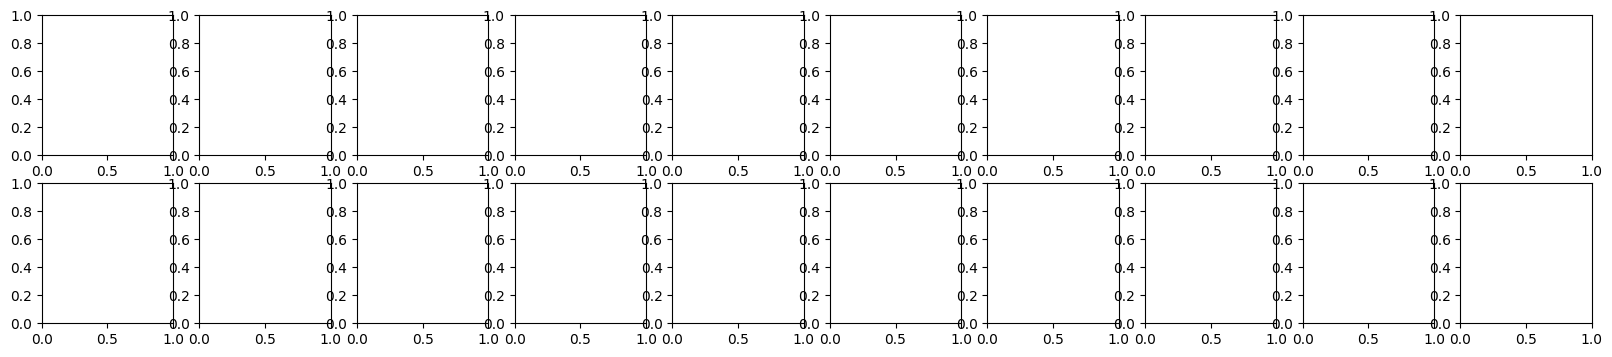

In [26]:
import matplotlib.pyplot as plt
import random

def plot_reconstructions(model, dataset, num_samples=10):
    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(2, num_samples, figsize=(20, 4))
    with torch.no_grad():
        for i, idx in enumerate(indices):
            orig_img,_ = test_dataset[idx]
            orig_img = orig_img.unsqueeze(0)
            orig_img = orig_img.to("cuda")
            reconstruction, _ = model(orig_img)

            orig_img_cpu = orig_img.squeeze(0).cpu()
            reconstruction_cpu = reconstruction.squeeze(0).cpu()
            orig_plot = orig_img_cpu.permute(1, 2, 0).numpy()
            recon_plot = reconstruction_cpu.permute(1, 2, 0).numpy()

            axes[0, i].imshow(orig_plot, cmap='gray')
            axes[0, i].set_title("Original")
            axes[0, i].axis('off')
            axes[1, i].imshow(recon_plot, cmap='gray')
            axes[1, i].set_title("Reconstruction")
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()
plot_reconstructions(model,test_dataset)

In [ ]:
embeddings_list = []
labels_list = []

with torch.no_grad():
    mnist_test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)
    for images, labels in mnist_test_loader:
        images = images.to("cuda")
        _, embedding = model(images)
        embeddings_list.append(embedding.cpu().numpy())
        labels_list.append(labels.cpu().numpy())

all_embeddings = np.concatenate(embeddings_list, axis=0)
all_labels = np.concatenate(labels_list, axis=0)

print(f"Extracted {all_embeddings.shape[0]} embeddings of dimension {all_embeddings.shape[1]}")

tsne = TSNE(n_components=2)
tsne_results = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=all_labels,
    palette=sns.color_palette("hsv", 10),
    legend='full',
    alpha=0.7
)
plt.title('t-SNE Visualization of MNIST Test Embeddings by Class')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

### Can we reconstruct other images?

Run the code below to evaluate your model on other datasets (with the same input dimension). What do you observe?

In [ ]:
EMNIST_dataset = torchvision.datasets.EMNIST(root='./data',
                                             train=False,
                                             split="letters",
                                             transform=transform,
                                             download=True)

FashionMNIST_dataset = torchvision.datasets.FashionMNIST(root='./data',
                                             train=False,
                                             transform=transform,
                                             download=True)

print(f"EMNIST dataset size: {len(EMNIST_dataset)}")
print(f"MNIST Test dataset size: {len(FashionMNIST_dataset)}")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn.functional as F
from torch.utils.data import DataLoader

def get_mse_losses(dataset, model, batch_size=128):
    losses = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    with torch.no_grad():
        for images, _ in loader:
            images = images.to("cuda")
            recon, _ = model(images)
            # Calculate per-sample MSE: mean over channels, height, and width
            loss = F.mse_loss(recon, images, reduction='none').mean(dim=[1, 2, 3])
            losses.extend(loss.cpu().tolist())
    return losses

results = []

mnist_train_losses = get_mse_losses(train_dataset, model)
for l in mnist_train_losses:
    results.append({'MSE_Loss': l, 'Dataset': 'MNIST_train'})
mnist_test_losses = get_mse_losses(test_dataset, model)
for l in mnist_test_losses:
    results.append({'MSE_Loss': l, 'Dataset': 'MNIST_test'})
emnist_losses = get_mse_losses(EMNIST_dataset, model)
for l in emnist_losses:
    results.append({'MSE_Loss': l, 'Dataset': 'EMNIST'})
fashion_mnist_losses = get_mse_losses(FashionMNIST_dataset, model)
for l in fashion_mnist_losses:
    results.append({'MSE_Loss': l, 'Dataset': 'FashionMNIST'})

loss_df = pd.DataFrame(results)
plt.figure(figsize=(12, 6))
sns.kdeplot(data=loss_df, x='MSE_Loss', hue='Dataset', common_norm=False, fill=True)
plt.title('Distribution of Reconstruction MSE Losses by Dataset')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

##

In [ ]:
plot_reconstructions(model,EMNIST_dataset)
plot_reconstructions(model,FashionMNIST_dataset)

## Practical part 4: detecting fraud with an autoencoder

Credit card fraud detection is a classic challenge in machine learning. One of the biggest hurdles in this domain is extreme class imbalance: the vast majority of transactions are perfectly normal, while fraudulent transactions are extremely rare. In this context training a standard binary classifier to distinguish between the two classes can be challenging.

Instead, let's explore a different approach. We will start by isolating the normal, legitimate transactions and train an autoencoder exclusively on those. Let's load the data, prepare our datasets, and train the model.

### Loading data

For this exercise we will use a dataset of credit card transaction collected  during a research collaboration of Worldline and the [Machine Learning Group of ULB](http://mlg.ulb.ac.be). For more details see the [kaggle data card](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).





In [ ]:
import kagglehub
import pandas as pd
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(path + "/creditcard.csv")
df.head()

For confidentiality reasons, we don't have access to the exact features recorded for each transactions. Instead we have the first 28 components of the PCA of the orignal features as well as the amount of the transaction. The only preprocessing we will do is to normalize the *amount* feature to have a mean of zero and standard deviation of 1.

In [ ]:
import sklearn.model_selection
clean_numpy = df[df["Class"]==0].drop(columns=["Time","Class"]).to_numpy()
fraud_numpy = df[df["Class"]==1].drop(columns=["Time","Class"]).to_numpy()
train_clean_numpy, test_clean_numpy = sklearn.model_selection.train_test_split(clean_numpy,train_size=0.9)
print(f"Clean training data size: {len(train_clean_numpy)}, clean test data size: {len(test_clean_numpy)}, fraud data size: {len(fraud_numpy)}")

We can observe the extrem class imbalance with more than 250k clean transactions for less than 500 fraudulent ones!

In [ ]:
mean_amount = train_clean_numpy[:,-1].mean()
std_amount = train_clean_numpy[:,-1].std()
print(f"Mean of Amount: {mean_amount:.4f}, Std of Amount: {std_amount:.4f}")
train_clean_numpy[:,-1] = (train_clean_numpy[:,-1] - mean_amount) / std_amount
test_clean_numpy[:,-1] = (test_clean_numpy[:,-1] - mean_amount)/ std_amount
fraud_numpy[:,-1] = (fraud_numpy[:,-1] - mean_amount) / std_amount

In [ ]:
train_dataset = torch.utils.data.TensorDataset(torch.tensor(train_clean_numpy,dtype=torch.float32))
test_clean_dataset = torch.utils.data.TensorDataset(torch.tensor(test_clean_numpy,dtype=torch.float32))
test_fraud_dataset = torch.utils.data.TensorDataset(torch.tensor(fraud_numpy,dtype=torch.float32))

### Design the autoencoder

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        # === ADD CODE HERE ===
        self.encoder = nn.Sequential(
            nn.Linear(29, 29),
            nn.ReLU(),
            nn.Linear(29,10),
            nn.ReLU(),
            nn.Linear(10,embedding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 10),
            nn.ReLU(),
            nn.Linear(10,29),
            nn.ReLU(),
            nn.Linear(29,29)
        )

    def forward(self, x):
        # === ADD CODE HERE ===
        embedding = self.encoder(x)
        reconstruction = self.decoder(embedding)
        return reconstruction, embedding
EMBEDDING_DIM=5
model = AutoEncoder(EMBEDDING_DIM)

In [ ]:
# Move model to GPU
# === ADD CODE HERE ===
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model.to("cuda")

# Train the model (tips: as the input dimension is small and there are a lot of records, a large batch size should fasten training without using much memory)
# === ADD CODE HERE ===
for epoch in range(20):
    # === ADD CODE HERE ===
    model.train()
    total_loss = 0
    for X, in DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=2):
        X = X.to("cuda")
        optimizer.zero_grad()
        reconstruction, _ = model(X)
        loss = loss_fn(reconstruction, X)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

### Fraud detection

In [ ]:
def get_mse_losses(dataset, model, batch_size=128):
    losses = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    with torch.no_grad():
        for inputs, in loader:
            inputs = inputs.to("cuda")
            recon, _ = model(inputs)
            loss = F.mse_loss(recon, inputs, reduction='none').mean(dim=[1])
            losses.extend(loss.cpu().tolist())
    return losses

clean_losses = get_mse_losses(test_clean_dataset, model)
fraud_losses = get_mse_losses(test_fraud_dataset, model)

Have a look at the clean and fraud losses, what do you observe? Does it remind you something we observed at the end of part 3?

Think how you could use your autoencoder to detect fraud (without retraining it). Display in the cell below the ROC curve of your fraud detection system. What would be your TPR (postive=fraud) if we tolerate a FPR of 1%? [^1]

(A straightforward way to compute these metrics is to use [sklearn roc curve function](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.htm), if you are not familiar with the notions of ROC curve, TPR and FPR see this [crash course](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall))

In [ ]:
# === ADD CODE HERE ===
from sklearn.metrics import roc_curve, RocCurveDisplay
fpr, tpr, thresholds = rocurve(y_true = [0 for _ in range(len(clean_losses))] + [1 for _ in range(len(fraud_losses))],
                               y_score = clean_losses + fraud_losses)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)
roc_display.plot()

i = sum(fpr<0.01) - 1
print(f"With a loss threshold of {thresholds[i]:.2f}, we can detect {tpr[i]*100:.2f}% of the fraudulent transaction with FPR of {fpr[i]*100:.2f}%")